# Summary: Gradient-Based Learning Applied to Document Recognition

**Authors:** Yann LeCun, Léon Bottou, Yoshua Bengio, Patrick Haffner
**Venue:** Proceedings of the IEEE, 1998, 86(11), pp. 2278–2324

# https://hal.science/hal-03926082/document

## Abstract

The paper argues that multilayer neural networks trained with back-propagation are the most successful instance of gradient-based learning, and that such methods can synthesize complex decision surfaces for high-dimensional pattern classification (e.g., handwritten characters) with minimal hand-crafted preprocessing. It introduces convolutional neural networks (CNNs) as an architecture specialized for the variability of two-dimensional (2-D) shapes and shows, via extensive benchmarking on a standard handwritten digit recognition task, that CNNs outperform all other techniques evaluated. Beyond isolated character recognition, the paper proposes graph transformer networks (GTNs), a paradigm that lets multimodule document-recognition systems — combining field extraction, segmentation, recognition, and language modeling — be trained jointly with gradient-based methods to optimize a single global performance measure. The framework is validated on two online handwriting recognition systems and on a commercially deployed GTN-based bank check reading system.

## Problems

- **Hand-crafted feature extraction is brittle and non-transferable.** Traditional pattern recognition pipelines separate a fixed, manually designed feature extractor from a trainable classifier; recognition accuracy hinges on the designer's ability to identify good features, a task that must be redone for every new problem.
- **Fully connected networks ignore input topology.** For image-like data, a fully connected network requires enormous numbers of training examples to learn shift/distortion invariance, since it has no built-in notion of spatial locality.
- **Multimodule document-recognition pipelines are trained piecemeal.** Real systems (field extraction → segmentation → recognition → language modeling) traditionally optimize each module separately using hand-labeled, presegmented data, which is expensive to produce and does not account for how the modules interact, nor does it optimize a global system-level objective.
- **Segmentation and recognition cannot be cleanly decoupled**, yet conventional systems commit to hard segmentation decisions before recognition, propagating irrecoverable errors.

## Proposed Solutions

1. **Convolutional Neural Networks (CNNs).** Networks combining local receptive fields, shared weights (weight replication across space), and spatial subsampling to build in shift, scale, and distortion invariance while sharply reducing the number of free parameters relative to fully connected networks.
2. **LeNet-5 architecture.** A concrete seven-layer CNN (plus input) instantiating these principles, used as the primary recognizer throughout the paper.
3. **Graph Transformer Networks (GTNs).** A generalization of gradient-based learning in which the objects passed between modules are not fixed-size vectors but weighted, directed graphs whose arcs carry data (e.g., images) and penalties; each module is a "graph transformer" whose parameters are learned by back-propagating a global loss through the entire graph-transformation pipeline via generalized transduction.
4. **Discriminative, global training criteria** (e.g., forward-Viterbi / discriminative forward loss) that let an entire document-recognition system — including implicit segmentation — be trained end-to-end from whole, weakly labeled documents rather than from manually segmented characters.

## Purpose

To demonstrate that (1) better pattern-recognition systems result from relying more on automatic, gradient-based learning and less on hand-designed heuristics, and (2) this principle extends beyond isolated-object classification to entire multimodule document-understanding pipelines, which can be recast as trainable graph transformer networks and optimized end-to-end.

## Methodology

**Convolutional network design (LeNet-5).**
LeNet-5 processes a $32 \times 32$ normalized input (background $= -0.1$, foreground $= 1.175$) through seven trainable layers:

| Layer | Type | Feature maps / units | Notes |
|---|---|---|---|
| C1 | Convolutional | 6 maps, $28\times28$ | $5\times5$ receptive field; 156 params, 122,304 connections |
| S2 | Subsampling | 6 maps, $14\times14$ | $2\times2$ averaging + trainable coefficient/bias; 12 params |
| C3 | Convolutional | 16 maps, $10\times10$ | Partial connectivity to S2 (Table 1) to break symmetry; 1,516 params |
| S4 | Subsampling | 16 maps, $5\times5$ | 32 params |
| C5 | Convolutional (full) | 120 units, $1\times1$ | Full connection to all S4 maps; 48,120 connections |
| F6 | Fully connected | 84 units | 10,164 params; scaled $\tanh$ squashing function |
| Output | Euclidean RBF | 10 units | One per class; distance to fixed class-prototype vectors |

The network has 345,308 connections but only about 60,000 trainable parameters due to weight sharing. The squashing (activation) function used throughout is

$$f(a) = A \tanh(Sa)$$

and the output RBF units compute

$$y_i = \sum_j (x_j - w_{ij})^2$$

i.e., the squared Euclidean distance between the F6 output vector and a fixed parameter vector representing each class.

**Dataset.** The MNIST dataset was constructed by mixing NIST Special Databases SD-1 and SD-3 (writer-disjoint splits) to obtain 60,000 training and 10,000 test images (a 10,000-image subset used in reported experiments), in three preprocessing variants: a "regular" $28\times28$/$32\times32$ size-normalized set, a "deslanted" $20\times20$ set, and a $16\times16$ set.

**Training procedure.** Stochastic (online) gradient descent was used rather than batch gradient, updating weights after each pattern over 20 passes through the training set. A stochastic diagonal Levenberg–Marquardt approximation set per-parameter learning rates, with a decreasing learning-rate schedule (0.0005 → 0.00001) across passes. Data augmentation via random affine distortions (translation, scaling, squeezing, shearing) was used to enlarge the effective training set.

**Comparative evaluation.** LeNet-5 was benchmarked against a wide range of alternative classifiers on the same MNIST test set: linear classifiers, pairwise linear classifiers, K-nearest-neighbor, a two-layer network with RBF hidden units, one- and two-hidden-layer fully connected MLPs, the smaller predecessor architectures LeNet-1 and LeNet-4, a boosted ensemble of three LeNet-4 networks, tangent-distance nearest-neighbor classifiers, and support vector machines (regular SVM, V-SVM, RS-SVM), comparing raw error rate, rejection performance, computational cost (multiply-accumulate operations), memory footprint, and training time.

**Multimodule/GTN systems.** The paper formalizes generalized transduction over weighted graphs, describes heuristic oversegmentation (HOS) methods, and presents two applications: (1) online handwriting recognition systems trained at the word level rather than on presegmented characters, and (2) a complete GTN-based bank check amount reader, which cascades a field-location transformer, a segmentation transformer, a recognition transformer (using LeNet-5 as the character classifier over 95 ASCII classes), a composition transformer (constrained by a stochastic grammar for check amounts), and a Viterbi transformer, all trained (where practical) end-to-end via back-propagated discriminative loss.

## Results

- LeNet-5 achieved a **0.95% test error rate** on the regular MNIST set without data augmentation, dropping to **0.8%** with distorted-pattern training data; only 82 of 10,000 test digits were misclassified, many of them ambiguous even to human readers.
- Increasing training-set size (15,000 → 30,000 → 60,000 examples, and further via synthetic distortion to 600,000) consistently improved accuracy, indicating LeNet-5 was not yet data-saturated.
- Comparative test error rates (regular MNIST test set) included: linear classifier 12%, pairwise linear classifier 7.6%, K-NN (baseline) 5.0%, one-hidden-layer MLP down to ~3.6% (RBF-based) or ~4.7–2.95% depending on size, two-hidden-layer MLP 3.05% (2.45% with distortion training), LeNet-1 1.7%, LeNet-4 1.1%, tangent-distance classifier 1.1%, regular SVM 1.4%, V-SVM 1.0% (best V-SVM variant 0.8%), RS-SVM 1.1%, LeNet-5 0.8%, and **Boosted LeNet-4 (ensemble of three networks) achieved the best result at 0.7%**.
- CNN-based methods required far fewer multiply-accumulate operations and far less memory than memory-based methods (K-NN, tangent distance, SVM), and trained substantially faster than SVM-based approaches while matching or exceeding their accuracy.
- The GTN-based check reading system, deployed commercially through NCR, correctly recognized **82% of machine-printed business checks with 1% error and 17% rejects**, a substantial improvement over the prior system's 68% correct / 1% error / 31% reject performance on the same test set; the system has processed millions of checks per day in production banking use since June 1996.
- Global training was shown to improve character-string-level recognition accuracy (error rates dropping from roughly 38%/12.4% to substantially lower levels under grammatical and normalization constraints) compared to locally trained, non-globally-optimized modules.

## Conclusions

- Gradient-based learning, when combined with an architecture (CNN) that encodes appropriate prior knowledge about 2-D shape invariances, can learn effective feature extractors directly from pixel data, eliminating the need for hand-crafted feature engineering in character recognition.
- The GTN framework generalizes back-propagation to systems whose functional architecture is a dynamically structured graph rather than a fixed vector pipeline, solving the credit-assignment problem for whole multimodule document-recognition systems and removing the need for hand-crafted segmentation heuristics, manual labeling, and manual parameter tuning.
- Segmentation and recognition should not be decoupled; postponing hard segmentation decisions and evaluating many hypotheses in parallel (as in HOS and generalized transduction) yields better performance than early, hard commitments.
- The success of the commercially deployed check-reading system demonstrates that gradient-based, globally trained GTNs are practical, cost-effective, and scalable to industrial deployment, separating algorithmic structure from domain-specific heuristics.
- The authors anticipate that as training data, computing power, and learning algorithms continue to improve, recognition systems will increasingly rely on automatic learning over manual engineering, and that the graph-transformation concept generalizes to other domains involving structured, graph-representable hypotheses (e.g., speech and visual scene analysis).

# Mathematical and Statistical Content

## Gradient-based learning applied to document recognition

---

## 1. Statistical Learning Theory

**Generalization gap bound**

$$
E_{\text{test}} - E_{\text{train}} \approx k\left(\frac{h}{P}\right)^{\alpha}
$$

Here $P$ is the number of training samples, $h$ is a measure of model "capacity" (effective complexity), $\alpha$ is a constant between 0.5 and 1, and $k$ is a constant.

**Role:** Motivates why minimizing training error alone is insufficient — the test/train error gap shrinks as training data grows and grows as capacity increases. This "capacity vs. data" tradeoff justifies restricting network capacity through architecture (convolution) rather than relying on unconstrained fully connected networks.

**Structural risk minimization**

$$
E(W) = E_{\text{train}}(W) + \beta H(W)
$$

$H(W)$ is a regularization function that penalizes parameters belonging to high-capacity regions of parameter space; $\beta$ is a constant.

**Role:** Formal justification for capacity control via built-in architectural constraints.

---

## 2. Gradient-Based Optimization

**Batch gradient descent**

$$
W_k = W_{k-1} - \eta \, \frac{\partial E(W)}{\partial W}
$$

**Stochastic (online) gradient descent**

$$
W_k = W_{k-1} - \eta \, \frac{\partial E^{p_k}(W)}{\partial W}
$$

Uses the gradient of the loss on a single example $p_k$ instead of the full training-set average.

**Role:** The actual algorithm used to train LeNet-5. The paper argues (Appendix B) that on large, redundant datasets, stochastic gradient descent converges faster than batch or second-order methods despite the noisier gradient estimate.

**Back-propagation as a Jacobian recurrence**

For a cascade of modules $X_n = F_n(W_n, X_{n-1})$:

$$
\frac{\partial E}{\partial W_n} = \frac{\partial F_n}{\partial W_n}(W_n, X_{n-1}) \cdot \frac{\partial E}{\partial X_n}
$$

$$
\frac{\partial E}{\partial X_{n-1}} = \frac{\partial F_n}{\partial X_{n-1}}(W_n, X_{n-1}) \cdot \frac{\partial E}{\partial X_n}
$$

**Role:** Generalizes ordinary back-propagation to *any* differentiable module chain — the mathematical bridge that later lets the same machinery train graph transformer networks, not just fixed-size vector layers.

---

## 3. Convolutional Network Mathematics

**Convolution / weight sharing**

$$
a_{ij} = b + \sum_{u,v} w_{uv} \, x_{i+u,\,j+v}, \qquad y_{ij} = f(a_{ij})
$$

**Role:** The same kernel $w_{uv}$ is reused at every spatial location. This (a) builds in shift-invariance — a shifted input produces a correspondingly shifted output — and (b) sharply reduces free parameters (LeNet-5 has 345,308 connections but only about 60,000 trainable parameters).

**Squashing (activation) function**

$$
f(a) = A \tanh(Sa), \qquad A = 1.7159
$$

**Role:** Used at every unit up to layer F6. The scale $A$ is chosen (Appendix A) so $f(1)=1$ and $f(-1)=-1$, keeping the network near the point of maximum curvature for faster convergence and away from slow, saturated regions.

**Output layer — Euclidean RBF units**

$$
y_i = \sum_j (x_j - w_{ij})^2
$$

Each output unit computes the squared Euclidean distance between the F6 activation vector and a fixed class-prototype vector.

**Role:** Interpreted as the unnormalized negative log-likelihood of a Gaussian in output space. Used instead of softmax/sigmoid outputs to support structured, confusable-class-aware output codes and to avoid a training pathology (the "collapse problem," discussed below).

**Weight initialization**

$$
W \sim \mathcal{U}\!\left(-\frac{2.4}{F_i},\ \frac{2.4}{F_i}\right)
$$

where $F_i$ is the fan-in (number of inputs) of the unit.

**Role:** Keeps the standard deviation of each unit's weighted sum in a consistent, well-behaved range across layers of different width, avoiding vanishing gradients (weights too small) or saturated sigmoids (weights too large).

---

## 4. Second-Order / Adaptive Learning-Rate Method

**Stochastic diagonal Levenberg–Marquardt**

Per-parameter learning rate:

$$
\eta_i = \frac{\eta}{\mu + h_{ii}}
$$

where $h_{ii}$ is an estimate of the diagonal Hessian term (second derivative of the loss with respect to parameter $i$) and $\mu$ is a hand-tuned safety constant. $h_{ii}$ is computed via a **Gauss–Newton approximation**:

$$
h_{ii} \approx \mathbb{E}\!\left[\frac{\partial^2 E^p}{\partial W_i^2}\right] \geq 0
$$

using a backward recurrence structurally analogous to ordinary back-propagation, re-estimated on only 500 samples before each training pass.

**Role:** Gives each shared weight its own adaptive step size. This matters because weight sharing makes the error surface ill-conditioned — a single shared parameter can strongly influence the output — so plain stochastic gradient descent needs this correction to train efficiently, while full Newton or quasi-Newton methods remain computationally infeasible ($O(N^2)$–$O(N^3)$ per update) at this scale.

**Weight-sharing gradient aggregation**

$$
\frac{\partial E}{\partial W_{ij}} = \sum_{(u,v) \in V_{ij}} \frac{\partial E}{\partial w_{uv}}
$$

where $V_{ij}$ is the set of individual connections that all share the tied parameter $W_{ij}$.

**Role:** The rule making convolutional weight sharing trainable by ordinary back-propagation — every physical connection's gradient contributes to the one shared parameter.

---

## 5. Graph-Based Sequence Scoring (Graph Transformer Networks)

**Viterbi (min-sum dynamic programming) recurrence**

$$
c(n) = \min_{a:\ \text{dest}(a) = n} \big[\, c(\text{src}(a)) + l(a) \,\big]
$$

**Role:** Finds the lowest-total-penalty path — the most likely label sequence — through the graph of segmentation/recognition hypotheses, in time linear in the number of arcs. This is the discrete-optimization backbone of the recognition system.

**Log-add ("soft-min") operation**

$$
\operatorname{logadd}_i(x_i) = -\log \sum_i e^{-x_i}
$$

used to combine parallel-path penalties:

$$
c(n) = \operatorname*{logadd}_{a:\ \text{dest}(a) = n} \big[\, c(\text{src}(a)) + l(a) \,\big]
$$

**Role:** The "forward algorithm" (borrowed from HMM training, e.g., Baum–Welch) — a smooth relaxation of the Viterbi minimum that accounts for all paths consistent with an interpretation, not just the single best one. Necessary so gradients can be back-propagated through the discrete graph search.

**Discriminative training losses**

$$
L_{\text{Viterbi}} = C_{cvit} - C_{vit}
$$

$$
L_{\text{forward}} = C_{dforw} - C_{forw}
$$

Each is the difference between (a) the penalty of the best path constrained to the correct label sequence and (b) the penalty of the best path overall (constrained or not). Both differences are provably $\geq 0$, equal to $0$ only when the model already prefers the correct answer.

**Role:** These losses let the entire multi-stage document/check-reading pipeline train end-to-end from whole-document labels, with no manual character segmentation needed — while avoiding a **collapse failure mode**, where an unconstrained sigmoid-output recognizer trivially minimizes loss by outputting a constant vector. The RBF output layer and discriminative (rather than purely generative) criteria are specifically designed to prevent this.

**Back-propagation through the forward penalty**

$$
\frac{\partial E}{\partial c_n} = \sum_{a \in U(n)} \frac{\partial E}{\partial c_{\text{dest}(a)}} \; e^{\,c_n + l(a) - c_{\text{dest}(a)}}
$$

with the corresponding arc-penalty derivatives obtained similarly.

**Role:** Shows gradients can flow smoothly through the "soft" min-sum computation, weighting each arc's influence by how close its path is to the lowest-penalty path — the mathematical trick letting a discrete graph-search module participate in ordinary gradient-based training just like any dense neural-network layer.

---

## 6. Summary Table

| Concept | Function in the Paper |
|---|---|
| VC-style generalization bound | Motivates restricting model capacity via architecture (convolution) rather than brute-force size |
| Gradient / stochastic gradient descent | Core optimization algorithm for all trained modules |
| Jacobian back-propagation recurrence | Generalized to justify training arbitrary differentiable module graphs (bridge to GTNs) |
| Convolution + weight sharing | Encodes translation invariance; reduces free parameters |
| $\tanh$ squashing function | Nonlinearity tuned for fast convergence |
| RBF output layer | Structured output coding; prevents trivial "collapse" solutions |
| Stochastic diagonal Levenberg–Marquardt | Adaptive per-weight learning rates for efficient, well-conditioned training of shared-weight networks |
| Viterbi algorithm | Discrete best-path decoding over segmentation/recognition hypothesis graphs |
| Log-add / forward algorithm | Differentiable "soft" relaxation of Viterbi enabling gradient flow through discrete graphs |
| Discriminative Viterbi/forward losses | End-to-end, segmentation-free training criteria for the full GTN document/check-reading pipeline |

| # | Key Problem / Research Gap | Limitation of Prior Work | Paper's Proposed Solution |
|---|---|---|---|
| 1 | Feature extraction in pattern recognition is traditionally hand-crafted and task-specific | Accuracy is bottlenecked by the designer's ability to identify good features; the process must be redone for every new task and rests on the questionable assumption that a human can capture all relevant input structure | Convolutional neural networks that learn feature extractors directly from raw pixel data via gradient-based training, removing the need for manual feature engineering |
| 2 | Fully connected networks ignore the 2-D topology of image inputs | Such networks require very large numbers of training examples and parameters to learn shift/distortion invariance, since no spatial locality or weight reuse is built in; they also scale poorly (tens of thousands of weights for even modest image sizes) | Architectural constraints — local receptive fields, shared weights (weight replication across space), and spatial subsampling — that build in shift and distortion invariance while sharply reducing the number of free parameters |
| 3 | No unified, rigorous way to train multimodule document-recognition pipelines (field extraction, segmentation, recognition, language modeling) | Each module is typically optimized separately using hand-labeled, presegmented data; the resulting system is manually tuned, tedious to build, and does not optimize any single global performance criterion | Graph transformer networks (GTNs) — a generalization of back-propagation to modules that operate on directed graphs (not just fixed-size vectors) — allowing all modules to be trained jointly from a single global, differentiable loss |
| 4 | Segmentation and recognition are conventionally treated as separate, sequential stages | Early, hard segmentation decisions are error-prone and irrecoverable; producing labeled data for correctly vs. incorrectly segmented characters is expensive and inherently ambiguous (e.g., ambiguous character cuts) | Heuristic oversegmentation (HOS) combined with graph-based representation of many candidate segmentations in parallel, with the final decision deferred until a global, differentiable scoring criterion is minimized |
| 5 | Standard neural-network training criteria for sequence-level models risk a "collapse" to trivial, uninformative solutions | Sigmoid/softmax-based recognizers trained under naive (nondiscriminative) losses can minimize loss by ignoring the input and outputting a constant, especially when the true segmentation/labels are not directly supervised | Discriminative training criteria (discriminative Viterbi and discriminative forward training) combined with fixed-parameter RBF output units, which structurally prevent the degenerate constant-output solution |
| 6 | Gradients cannot obviously be propagated through discrete, graph-structured computations (e.g., Viterbi decoding, dynamic segmentation) | Prior systems (e.g., HMM-based speech/handwriting recognizers) rely on probabilistic generative models with normalized likelihoods (e.g., Baum–Welch), which cannot be preserved when non-generative modules such as NNs are integrated | A generalized transduction framework and a differentiable "forward algorithm" (log-add / soft-min) that allow gradients to be back-propagated through graph transformations, min-selection, and path scoring |
| 7 | Second-order optimization methods (Newton, quasi-Newton, conjugate gradient) are theoretically attractive but computationally infeasible for large networks | These methods require $O(N^2)$–$O(N^3)$ operations per update or rely on batch-mode "conjugate descent directions" that do not scale to large, redundant training sets | A stochastic diagonal Levenberg–Marquardt method that estimates a per-parameter adaptive learning rate cheaply (via a Gauss–Newton diagonal Hessian approximation re-estimated on a small sample subset), compatible with online stochastic gradient descent |
| 8 | Real-world deployment of automated document/check readers demands both accuracy and computational/memory efficiency | Competing high-accuracy methods (e.g., SVMs, tangent-distance, K-NN) incur substantially higher computational cost, memory requirements, or training time, limiting industrial viability | LeNet-5 and its GTN-based check-reading system achieve competitive or superior accuracy at a fraction of the computational/memory cost, enabling commercial-scale deployment (millions of checks processed daily) |

In [1]:

# Gradient based learning is a general approach to training machines by tuning the parameters (weights/biaes)
# to miniminze a loss function of a deep learning model with respect to that loss function
# by using the gradients (the derivative) of the loss function with repsect to the parameters of the model

# the paper's main claim, bet is that gradient-based learning scales to very large, complex system

# training deep multi-layer neural network (via back-propgation)
# training convolutioal neural network (learn feature detectors (filter/kernsls))

# the papers goes through two flavours:

# this approach is accurte, but slow
# 1. Batch Gradient Descent: compute the loss function and its gradients over the entire training set and then update the parsm

# this approach is way faster than the previous apprach (batch size = 32/64/128)
# 2. Stochastic Gradient Descent: compute the loss function and its gradients after every single sample (1) and update the param

# the paper intorduces a new learning approach (graph transformer network (GTN))

# the paper's main ideas are:
# 1. Feature Extraction should be learned, not hand-crafted
# 2. Whole multi-stage document-recognition should be trained end-to-end not module-by-module

import io # a python module to render/display figures/dashboard directly inline

import math # a math library in python to do many operation of the model

import random # a random number generator python library

import numpy as np # a python main fundamental numerical processing library (crate array, manipulate them using math ops)

import torch # core tensor library (tensors/manipulate them using math ops)

import torch.nn as nn # many several nerual network moduls/compoentns (Linear, Dense, Dropout, Conv, Subsampling)

import torch.nn.functional as F # main functional API interface (Softmax, loss function layers)

from torch.utils.data import Dataset, DataLoader # create our own data pipelines by using Dataset wrapper, DataLoader iterable data

import matplotlib # get the main plotting library into python ecosystem
matplotlib.use("Agg") # use Agg state in matplotlib
import matplotlib.pyplot as plt # import the python moudle for plotting histogram/plots inside colab
import matplotlib.gridspec as gridspec # importing the function that creates multi-panel custom layout

from PIL import Image, ImageDraw # reading images/ to draw images inside google colab

from IPython.display import display, Image as IPyImage # function/classes to dispaly images inline with having to call plt.show

# ----------------------------------------------------------------------
# Reproducibility
# ----------------------------------------------------------------------
SEED = 42 # a seed value set to be 42 (that means we can run the notebook over and over to get the same results)
random.seed(SEED) # make our python random moudule always generate the same flavour of numbers
np.random.seed(SEED) # make our numpy moudle generate the same flavour of numbers
torch.manual_seed(SEED) # make our python CPU-side gernated the same flavour of numbers

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
from datasets import load_dataset # hugging face own dataset library for laoding/downloading dataset into colab

# --- Load real MNIST from the Hugging Face Hub ----------------------------
# "ylecun/mnist" is the canonical MNIST dataset (mirrored on the HF Hub by
# the paper's own first author): 60,000 train / 10,000 test images, each a
# 28x28 grayscale PIL Image with an integer "label" field.
hf_mnist_train = load_dataset("ylecun/mnist", split="train") # pull in the training dataset
hf_mnist_test = load_dataset("ylecun/mnist", split="test") # pull in our teseting dataset

# this dataset MNIST is an object of mulitple dict each dict:
# 1. "image": PIL.Image object
# 2. "label": an integer label category

# this function will adpat or normalize our MNIST dataset examples into the paper's required format
def hf_mnist_example_to_tensor(example):
    """
    Converts a single Hugging Face MNIST example (a 28x28 'L'-mode PIL
    Image + integer 'label') into a (1, 32, 32) float tensor in [0, 1],
    matching the paper's 32x32 input size (Sec. II-B): the raw 28x28 image
    is zero-padded by 2 pixels on every side -> 32x32, then scaled to [0,1].
    """
    # if for any reason the single example MNIST image (sample) is not grayscale format we have to convert it
    img = example["image"]  # PIL.Image, mode "L", size (28, 28)

    if img.mode != "L": # this image is not a grayscale (not a single-channel image)
        img = img.convert("L") # convert that image into a grayscale (single-channel image)

    # create a blank canvas of size (32, 32) filled with the black pixel color

    padded = Image.new("L", (32, 32), color=0) # fill this canvas with black pixels (color=0)
    # pasting our original 28*28 pixel image onto that canvas and center it exactly
    padded.paste(img, (2, 2))  # centers the 28x28 digit inside the 32x32 field

    # convert PIL image object into a numpy array

    arr = np.asarray(padded, dtype=np.float32) / 255.0  # -> [0, 1] normalize our pixel values into a range (0, 1)
    # convert a numpy into a pytorch tensor (compatible object for neural network)
    # input shape (32, 32) -> output shape (1, 32, 32)
    # to ensure it contains float values rather than integer
    tensor = torch.from_numpy(arr).unsqueeze(0).float()  # (1, 32, 32)

    label = int(example["label"])

    return tensor, label  # a tuple of (image, label) (PyTorch tensor object, int64 label)


# Adapting our MNST HF dataset into pytorch compatible dataset object
class DigitDataset(Dataset): # subclassing from torch.utils.data.Dataset

    """
    Custom PyTorch Dataset yielding (image, label) pairs matching the
    paper's exact input/output structure (Sec. III-A):
        input  : (1, 32, 32) float tensor, background=-0.1, foreground=1.175
        target : integer class label in {0, ..., 9}
    Wraps a Hugging Face Hub MNIST split (over a given subset of indices).
    """

    def __init__(self, hf_split, indices):
        self.hf_split = hf_split # hf_split is our actual HF dataset object (train or test)
        self.indices = indices # the actual indices (index values) for choosing a subset from that split

    # this method will return the actual number of samples inside our HF split indices
    def __len__(self):
        return len(self.indices) # given this number of indices (sample) how many batches to create (construct)

    # the method __getitem__
    def __getitem__(self, idx):
        # translaing our idx number into an actaul index (indices) list
        real_idx = self.indices[idx]
        # return a sample in a lazy loading fashion
        example = self.hf_split[real_idx]                # dict: {"image": PIL, "label": int}
        # preprocess (prepare) our image object into ready to go pytorch tensor foramt
        img01, label = hf_mnist_example_to_tensor(example)  # (1, 32, 32) in [0, 1] normalized pixel value


        # The values of the input pixels are normalized so that the background level (white)
        # corresponds to a value of −0.1 and the foreground (black) corresponds to 1.175.

        # an extremely black pixel (0 * 1.275 - 0.1) = -0.1
        # an exteremly white pixel (1 * 1.275 - 0.1) = 1.275 - 0.1 = 1.175

        x = img01 * 1.275 - 0.1  # paper-style normalization (Sec. II-B): bg=-0.1, fg=1.175

        y = torch.tensor(label, dtype=torch.long) # torch.int64

        return x, y # a tuple of (image, label) pair


# --- Dataset sizes: modest, for a 5-epoch educational run ----------------
N_TRAIN = 1500   # ~150 examples/class; enough to show a real 5-epoch learning curve
N_VAL = 300      # ~30 examples/class held out for validation
# number of training samples is set to be 1500 samples
# number of testing samples is set to be 300 samples

train_ds = DigitDataset(hf_mnist_train, list(range(N_TRAIN)))
val_ds = DigitDataset(hf_mnist_test, list(range(N_VAL)))

# batch size to 32
BATCH_SIZE = 32
# pytorch iterator object
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False) # it does not matter we shuffle/not shuffling

# "Classes" for this paper's task = digit labels 0-9 (Sec. III, Fig. 4)
# creating a classes list of the names of categories inside MNSIT
CLASSES = [str(d) for d in range(10)]

# --- Sanity check ----------------------------------------------------------
print("=== Dataset sanity check ===")
print(f"Train size: {len(train_ds)} | Val size: {len(val_ds)}")
_xb, _yb = next(iter(train_loader))
print(f"Batch input shape:  {tuple(_xb.shape)}  (N, C, H, W)")
print(f"Batch target shape: {tuple(_yb.shape)}")
print(f"Target value range: [{_yb.min().item()}, {_yb.max().item()}]")
print(f"Class vocabulary (paper's 'class' unit = digit label): {CLASSES}")

README.md:   0%|          | 0.00/6.97k [00:00<?, ?B/s]

mnist/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 15.6MB            

mnist/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

mnist/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.60MB            

mnist/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

=== Dataset sanity check ===
Train size: 1500 | Val size: 300
Batch input shape:  (32, 1, 32, 32)  (N, C, H, W)
Batch target shape: (32,)
Target value range: [0, 9]
Class vocabulary (paper's 'class' unit = digit label): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [3]:
hf_mnist_train[0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=28x28>,
 'label': 5}

In [4]:
hf_mnist_test[0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=28x28>,
 'label': 7}

In [5]:
images, labels = next(iter(train_loader))

In [6]:
images.shape

torch.Size([32, 1, 32, 32])

In [7]:
labels

tensor([1, 7, 0, 7, 7, 4, 8, 0, 2, 1, 6, 7, 7, 7, 1, 9, 4, 5, 9, 2, 1, 4, 6, 9,
        5, 3, 4, 6, 9, 0, 3, 1])

In [8]:
torch.ones(size=(1, 10, 1, 1))

tensor([[[[1.]],

         [[1.]],

         [[1.]],

         [[1.]],

         [[1.]],

         [[1.]],

         [[1.]],

         [[1.]],

         [[1.]],

         [[1.]]]])

In [9]:
C3_CONNECTIONS = [
    [0, 1, 2], [1, 2, 3], [2, 3, 4], [3, 4, 5], [4, 5, 0], [5, 0, 1], # the first 6 lists are the first group
    [0, 1, 2, 3], [1, 2, 3, 4], [2, 3, 4, 5], [3, 4, 5, 0], [4, 5, 0, 1], [5, 0, 1, 2],
    [0, 1, 3, 4], [1, 2, 4, 5], [0, 2, 3, 5],
    [0, 1, 2, 3, 4, 5], # the complete entire set of the feature map
]


nn.ModuleList([
            nn.Conv2d(len(idxs), 1, kernel_size=5) for idxs in C3_CONNECTIONS
        ])

ModuleList(
  (0-5): 6 x Conv2d(3, 1, kernel_size=(5, 5), stride=(1, 1))
  (6-14): 9 x Conv2d(4, 1, kernel_size=(5, 5), stride=(1, 1))
  (15): Conv2d(6, 1, kernel_size=(5, 5), stride=(1, 1))
)

In [10]:
# ============================================================================
# 2. MODEL: LeNet-5 (Sec. II-B), implemented layer-by-layer per the paper
# ============================================================================

# rather than using a normal tanh activation function (saturaiton problem) -inf, +inf, (-1, 1)
# an alterative tanh activation function (a scaled tanh activation funciton)
# after every layers that contains weigths will insert a scaled activation tanh function

# to avoid the problem saturation of the tanh activation function the authors porpose a new scaled tanh version

# F(X) = A * tanh( S * X )

# as X approches -> -inf it will saturate into -1
# as X approches -> +inf it will saturate into +1

class ScaledTanh(nn.Module):
    """
    Paper's squashing function, Appendix A / Eq. 6: f(a) = A * tanh(S * a),
    with A = 1.7159, S = 2/3, chosen so f(1)=1, f(-1)=-1, keeping the
    network near the point of maximum curvature for faster convergence.
    """

    def __init__(self):
        super().__init__()
        # nn.Parameter()
        # these values are carefully chosed by the authors of the papers
        self.A = 1.7159 # a constant value (not changed ever)
        self.S = 2.0 / 3.0 # a constant value (not chagned ever)

    # the method forward will impelment the sclaed tanh activation
    def forward(self, x):
        return self.A * torch.tanh(self.S * x) # that does not saturate (it will be more smooth)


# 1. Define a loss function E(W) : a function that measures how badly the system is performing
# 2. Compute the gradients DE/DW: this tell you, for each param, which direction to move into to actual minimize the loss
# 3. Update the parameters: change the param into the step of decreasing the loss value

# if you use the normal regular avgpool2d layer in pytorch it will be static (no learnable parmas)
# if you use the below class object it will be leaning (learnable coeff + learnabel trainig bias vector)

# in the original implementaiotn of the AvgPool2D layer it will just one operation
# A 2X2 averge pool and then return the results (B, 10, 28, 28) -> (B, 10, 14, 14)

# but in the paper the authors are actually implemnting a new idea os average pooling
# 1. take the average (the mean) by applying a 2X2 window
# 2. Multiply that feature map by a learnable (trainable) coeff (scale)
# 3. Add a trainable (learnable) bias value (offset)
# 4. apply the activation function

class SubsamplingLayer(nn.Module):
    """
    Paper's S2 / S4 layers (Sec. II-B) -- NOT plain average pooling. Each
    feature map: local 2x2 non-overlapping average, then a single
    TRAINABLE scalar coefficient and TRAINABLE scalar bias PER FEATURE MAP,
    then the scaled-tanh squashing function.
    """

    # if you start training multplying by one will not effect anything
    # if you start training adding zero will not effect anything

    # featuer_map = feature_map * 1 + 0 (training will actually figure out the best coeff + bias)

    def __init__(self, n_channels): # how many feature maps to averge over
        # it will initialize the internal setting of the parent nn.Module class
        super().__init__()
        # this will be our local 2X2 average pool layer
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2) # non-overlapping block for every average over ope
        # Creating the trainable params (coeff + bias additions)
        # the shape should be broadcastble (with the featuer map size (length))
        self.coeff = nn.Parameter(torch.ones(1, n_channels, 1, 1)) # a tensor of shape (1, 10, 1, 1)
        # inform ptorch that it has to compute gradients (derivaties) for this tensor of learnable biases
        self.bias = nn.Parameter(torch.zeros(1, n_channels, 1, 1))

        self.act = ScaledTanh() # call our scaled activation tanh funciton
    # this method forward will implement the forward compaution
    def forward(self, x):
        # applying the first operation (average pool over 2X2 non-overlapping region)
        x = self.pool(x) # slide over a window of size (2x2)

        x = x * self.coeff + self.bias # plugging in some learnable (trainable) params

        return self.act(x) # use our scaled tanh function to activate it


# Table 1 (Sec. II-B): which of S2's 6 feature maps feed each of C3's 16
# feature maps -- first 6 take contiguous triples, next 6 take contiguous
# quadruples, next 3 take discontinuous quadruples, last 1 takes all six.

# this is a list of 16 differet list (defining the connection from S2 layer and how it related to C3 layer)
# nn.Conv2d() (it will map (connect) every feature map from S2 to every map in the layer C3)

C3_CONNECTIONS = [
    [0, 1, 2], [1, 2, 3], [2, 3, 4], [3, 4, 5], [4, 5, 0], [5, 0, 1], # the first 6 lists are the first group
    [0, 1, 2, 3], [1, 2, 3, 4], [2, 3, 4, 5], [3, 4, 5, 0], [4, 5, 0, 1], [5, 0, 1, 2],
    [0, 1, 3, 4], [1, 2, 4, 5], [0, 2, 3, 5],
    [0, 1, 2, 3, 4, 5], # the complete entire set of the feature map
]


class SparseC3Layer(nn.Module): # pytorch's base class for neural network (nn.Module)
    """
    Paper's C3 layer (Sec. II-B, Table 1): 16 feature maps, each connected
    to only a SUBSET of S2's 6 maps (not fully connected), forcing
    different C3 maps to learn complementary features. Implemented as 16
    independent small nn.Conv2d modules, each seeing only its assigned
    input-channel subset, concatenated into one 16-channel output.
    """
    # as a default it will use the C3 connection list from above
    # kernel size is how large (how big) our window will be
    def __init__(self, connections=C3_CONNECTIONS, kernel_size=5):
        super().__init__()

        self.connections = connections

        # this will create 16 differnet convolution layer
        # one feature map as output
        # len(idxs) as input channel
        self.convs = nn.ModuleList([
            nn.Conv2d(len(idxs), 1, kernel_size=kernel_size) for idxs in connections
        ])
        # new activation function
        self.act = ScaledTanh()

    # building the method forward
    def forward(self, x):
        # store the outputs of the convolution inside one list object
        outs = [conv(x[:, idxs, :, :]) for idxs, conv in zip(self.connections, self.convs)]

        return self.act(torch.cat(outs, dim=1))

# this class build the final layer of a LeNet5-architecture
# RBF is short for a radial basis function
# in a modern model you would expect the final layer to be a normal standard nn.Linear()
# this layer computes Euclidean distances and choose the miniumum distance

# y = sum(x - w)^2
# .to(device)
# .train()/.eval() / autograd module
class RBFOutputLayer(nn.Module): # because we would like to use this layer inside a neural network (LetNet5)
    """
    Paper's output layer (Sec. II-B, Eq. 7): Euclidean RBF units, one per
    class, computing y_i = sum_j (x_j - w_ij)^2 against a FIXED (non-
    trainable) class-prototype vector. y_i is a PENALTY (distance), so
    classification picks argmin, not argmax.

    SIMPLIFICATION (see module docstring): prototypes are a fixed,
    deterministic, class-specific +1/-1 code (length 84) rather than the
    paper's hand-designed stylized-bitmap font (Fig. 3).
    """
    # n_classes = number of classes (0-9) 10 classes
    # n_features = number of features inside every feature vector (84)
    def __init__(self, n_classes=10, n_features=84):

        super().__init__() # call the method __init__ of the super parent class
        # pre-allocating a placeholder tensor of shape (10, 84)
        prototypes = torch.empty(n_classes, n_features) # shape (10, 84)
        # the prototypes tensor variable will contain 10 vector, each vector of size (84) of numbers (-1, +1)
        for c in range(n_classes):
            # determinstic/reproducbility
            # distinctive (different numbers from class to class)
            g = torch.Generator().manual_seed(1000 + c) # 1000/1001/1002/1003... 1009
            # generating a random tensor of shpae 84 that contains (0, 1) 2 here is excluded
            # 0.0 * 2 - 1 = -1
            # 1.0 * 2 - 1 = +1
            prototypes[c] = torch.randint(0, 2, (n_features,), generator=g).float() * 2 - 1

        # why not use nn.Parameter() - would actually compute the gradients of those nubmers and update them
        # why not sotre it directly inside an attributes - becuase it will not move onto target device .to(device)


        # this function is used sepcifcialy for this purpose where
        # 1. you would like to create a tensor that is part of the model - movable to device - savable with the model
        # 2. you would not like to train these parameters becuase they are fixed constant value

        self.register_buffer("prototypes", prototypes)  # fixed, never trained
    # the method forward will define the forward compuation of the model
    # this method will be called whenever you call layer(X)
    def forward(self, x):
        # x input shape (10, 84) -> output shape (10, 1, 84)
        # prototypes input shape (10, 84) -> output shape (1, 10, 84)
        # the final tensor shape (10, 10, 84)
        diff = x.unsqueeze(1) - self.prototypes.unsqueeze(0)   # (N, n_classes, n_features)

        return (diff ** 2).sum(dim=2)                           # (N, n_classes) penalties

# this class assembles everything into one compelete class pytorch module
class LeNet5(nn.Module): # that means we are getting all the standard machinery of the creating deep neural network
    """
    Full LeNet-5 (Sec. II-B): C1 -> S2 -> C3 -> S4 -> C5 -> F6 -> RBF output.
    Input: (N, 1, 32, 32).
    """

    def __init__(self):
        super().__init__()
        # a fully-conncted convolution layer
        # the first convolution layer receives a single-channel grayscale input image
        # produces 6 feature maps (apply 6 different kerenls/filters)
        # with no padding (valid padding the output will be lower in size compared to the input)
        self.C1 = nn.Conv2d(1, 6, kernel_size=5)       # 32x32 -> 28x28, 6 maps
        # in order for pytorch to recognize that this is an actual neural network module (layer)
        # it has to inherit (subclass) from nn.Module()
        self.act1 = ScaledTanh() # apply a non-linear squashing activatio function


        # a learned subsmapling layer implented in our prev
        self.S2 = SubsamplingLayer(6)                  # 28x28 -> 14x14

        # we would like to limit (bound) the connectivity of the neuron to some specfic (hand-design) conneciton
        self.C3 = SparseC3Layer()                       # 14x14 -> 10x10, 16 maps (Table 1)
        # input shape (B, C, H, W) -> (B, C, H/2, W/2)
        self.S4 = SubsamplingLayer(16)                  # 10x10 -> 5x5
        # the output feature map is of size 5 and we are applying a kernel of 5

        self.C5 = nn.Conv2d(16, 120, kernel_size=5)    # 5x5 -> 1x1, 120 maps (= full connection)

        self.act5 = ScaledTanh()
        # this layer will map (convert) the 120 feature vectors into 84 feature vector
        self.F6 = nn.Linear(120, 84)                    # fully connected, 84 units
        self.act6 = ScaledTanh()
        # the smaller the outputs is that the better the score is (choose that)
        # the higher the output is the worse the score is (we do not choose)

        # this final outputs is producing penalities (not logits) which are squared dist of inputs vs. weights

        self.output = RBFOutputLayer(n_classes=10, n_features=84)  # Eq. 7

    def forward(self, x):
        # intput shape (32, 1, 32, 32) -> (32, 1, 28, 28)
        x = self.act1(self.C1(x)) # apply non-linear squashing function
        # input shape (32, 1, 28, 28) -> (32, 1, 14, 14)
        x = self.S2(x) # subsmpaling layer two  (learnable coeff + learnable bias)
        # apply the second non-fully-connctionted convolutoin layer
        x = self.C3(x)

        x = self.S4(x)

        x = self.act5(self.C5(x))

        x = x.view(x.size(0), -1)   # (N, 120)

        x = self.act6(self.F6(x))   # (N, 84)
        return self.output(x)       # (N, 10) RBF penalties


model = LeNet5().to(device) # instanitate the model LeNet-5 and move to the target device

In [11]:

# ============================================================================
# 3. LOSS (Eq. 9, Sec. II-C) AND PREDICTION
# ============================================================================
# now let's build the loss function

# y is the model's raw outputs
# targets is the actual ground truth targets
# j_constnt : a value that is constant and fixed set to be : 1
# a penalty is simply the squared distance of the inputs compared to the weights
def map_criterion(y, targets, j_const=1.0):
    """
    Paper's MAP (maximum a posteriori) discriminative criterion, Eq. 9:
        E(W) = (1/P) * sum_p [ y_Dp + log( e^{-j} + sum_i e^{-y_i} ) ]
    - y_Dp: RBF penalty of the CORRECT class (pushed DOWN).
    - log(e^-j + sum_i e^-y_i): competitive term that pushes UP the
      penalties of all classes, preventing the "collapse" pathology
      (Sec. VI-A) where an unconstrained recognizer could trivially
      minimize loss by ignoring the input.
    - j_const: the constant "j" (paper leaves exact value to the
      implementer) controlling the strength of the repulsive term.
    Returns (total_loss, y_correct_term, competitive_term) so each
    component can be logged separately (dashboard Panel B).
    """
    # in modern implementation you could use the Cross Entropy Loss function

    batch_size = y.size(0) # how many sample in a batch

    # we are using advanced indexing by using two parallel index system
    # indexing to grab (fetch) the elements in pairs (pred_0, truth_0)
    y_correct = y[torch.arange(batch_size, device=y.device), targets]
    # (-) is just to flip the sign of J_consnt (+ -> -) (- -> +)
    # we have to stick to the device + exact data type of the y tensor
    j_tensor = torch.tensor(-j_const, device=y.device, dtype=y.dtype)
    # exponentiate our j_tensor value and add (sum) with the exp of -y
    # apply the natural logarithm of the outputs and then store into the var competitive
    competitive = torch.log(torch.exp(j_tensor) + torch.exp(-y).sum(dim=1))

    loss_per_sample = y_correct + competitive # add (sum) both the y_correct + competivtive

    return loss_per_sample.mean(), y_correct.mean(), competitive.mean()

# three steps to implement gradient-based learning:

# 1. define the loss function (how badly the network is actually performing)
# 2. compute the gradients (the gradient is a derivative of how much to change the parm with respect to loss)
# 3. update the parmeters (update the param based on that gradient) Adam/SGD

# we will build two small funcntion that convert RBF output layer into something meaningful + intepretabl

# this function turns the model's raw output into a hard class classifcation output (label)

# in a softmax layer (higher = more likely)
# in RBF (radial basis function) (lower = better match)
def predict(y):
    """Classification rule: pick the class with the SMALLEST RBF penalty (argmin)."""
    return torch.argmin(y, dim=1) # return the index at which the lowest possible item lay in

# return th soft confidence of our model's raw output
def confidence_scores(y):
    """
    Soft 'confidence' derived from RBF penalties via the paper's own
    probabilistic reading of the RBF output (Sec. II-B: "unnormalized
    negative log-likelihood of a Gaussian"): p_i ~ softmax(-y_i).
    Used only for the dashboard's confidence panel.
    """
    # negating y (-y) to flip the sign of the values so that small value -> large value
    # large values -> small values
    return F.softmax(-y, dim=1) # return a probability density esitmation by taking softmax of values (-y)

In [12]:

# ============================================================================
# 4. TRAINING LOOP (5 epochs, per task instructions)
# ============================================================================
# creating a stochatic gradient descent

optimizer = torch.optim.SGD(model.parameters(), lr=0.01) # a small tiny learning rate
# NOTE: substitutes the paper's stochastic diagonal Levenberg-Marquardt
# adaptive learning rate (Appendix C) with plain SGD on the same Eq. 9
# loss -- stated simplification (see top docstring, item c).

N_EPOCHS = 5 # 5 complete passes over the entire training set
J_CONST = 1.0 # j_const is a small value set to be 1

# differnt metrics to track the model later on by visualizing these statistics
history = {
    "train_loss": [], "val_loss": [],
    "train_ycorrect": [], "val_ycorrect": [],
    "train_competitive": [], "val_competitive": [],
    "train_acc": [], "val_acc": [],
    "per_class_acc_by_epoch": [],  # list of 10-length arrays, one per epoch (val set)
}

# takes in a loader (dataloader) + training mode (True/False)
def run_epoch(loader, train=True):

    model.train(train) # set the model mode into trianign mode

    total_loss = total_yc = total_comp = total_correct = total_n = 0.0

    class_correct = np.zeros(10)
    class_total = np.zeros(10)

    # iterating over dataloder to yield batches (data of batches)
    for x, y in loader:

        x, y = x.to(device), y.to(device)

        if train:
            optimizer.zero_grad() # set the old gradients to be zero before doing one new trianing step

        # output is penalities (distances between X input vector vs. the weights (prototypes) of the model)
        out = model(x) # (N, C, H, W) -> (32, 1, 32, 32)

        # loss calcuation
        loss, yc, comp = map_criterion(out, y, j_const=J_CONST)

        if train:
            # bakcprop will compute the gradients of the loss with respect to the weights/biases
            loss.backward() # ask backprop to compute gradients and backpoprgate them across layer (layer by layer)
            # optimizer will chagne the param in the direction that ensure to decrease lower our loss function
            optimizer.step() # ask the optimizer to change the weights/biases by doing one optimizer step

        # make prediction of the model

        preds = predict(out) # it will actually choose the minium value of all the values

        correct = (preds == y) # a boolean tensor of the matching items (elments)

        bs = x.size(0)

        total_loss += loss.item() * bs # convert the loss from a mean (average) into a total

        total_yc += yc.item() * bs

        total_comp += comp.item() * bs

        total_correct += correct.sum().item()

        total_n += bs
        for c in range(10):
            mask = (y == c) # a mask tensor (boolean tensor)
            # calculating the total number of smaples
            class_total[c] += mask.sum().item()
            # calculating the total number of correctly predicted sampesl
            class_correct[c] += (correct & mask).sum().item()

    avg_loss = total_loss / total_n
    avg_yc = total_yc / total_n
    avg_comp = total_comp / total_n

    acc = total_correct / total_n
    per_class_acc = class_correct / np.maximum(class_total, 1)

    return avg_loss, avg_yc, avg_comp, acc, per_class_acc


print("\n=== Training (5 epochs, MAP loss Eq. 9) ===")
for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_yc, tr_comp, tr_acc, _ = run_epoch(train_loader, train=True)

    with torch.no_grad():# turn off the gradient tracking
        va_loss, va_yc, va_comp, va_acc, va_per_class = run_epoch(val_loader, train=False)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_ycorrect"].append(tr_yc)
    history["val_ycorrect"].append(va_yc)
    history["train_competitive"].append(tr_comp)
    history["val_competitive"].append(va_comp)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["per_class_acc_by_epoch"].append(va_per_class)

    print(f"Epoch {epoch}/{N_EPOCHS} | train loss {tr_loss:.4f} acc {tr_acc:.3f} "
          f"| val loss {va_loss:.4f} acc {va_acc:.3f} (err {100*(1-va_acc):.2f}%)")


=== Training (5 epochs, MAP loss Eq. 9) ===
Epoch 1/5 | train loss 56.8783 acc 0.534 | val loss 42.9701 acc 0.727 (err 27.33%)
Epoch 2/5 | train loss 35.6456 acc 0.807 | val loss 34.2259 acc 0.817 (err 18.33%)
Epoch 3/5 | train loss 26.1964 acc 0.864 | val loss 25.5525 acc 0.880 (err 12.00%)
Epoch 4/5 | train loss 19.5416 acc 0.903 | val loss 17.8340 acc 0.943 (err 5.67%)
Epoch 5/5 | train loss 14.6460 acc 0.935 | val loss 14.0148 acc 0.950 (err 5.00%)


In [13]:
# ============================================================================
# 5. PREDICTION PIPELINE / QUALITATIVE EXAMPLES
# ============================================================================

def collect_predictions(loader):
    model.eval()
    all_preds, all_targets, all_conf = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            all_preds.append(predict(out).cpu())
            all_targets.append(y.cpu())
            all_conf.append(confidence_scores(out).cpu())
    return torch.cat(all_preds), torch.cat(all_targets), torch.cat(all_conf)


val_preds, val_targets, val_conf = collect_predictions(val_loader)

n_classes = 10
confusion = np.zeros((n_classes, n_classes), dtype=np.int64)
for t, p in zip(val_targets.numpy(), val_preds.numpy()):
    confusion[t, p] += 1
row_sums = confusion.sum(axis=1, keepdims=True)
confusion_norm = confusion / np.maximum(row_sums, 1)

pred_conf = val_conf.gather(1, val_preds.unsqueeze(1)).squeeze(1).numpy()
correct_mask = (val_preds == val_targets).numpy()
conf_correct = pred_conf[correct_mask]
conf_incorrect = pred_conf[~correct_mask]

print("\n=== Qualitative predictions (input: 32x32 digit image -> output: class label) ===")
sample_idx = random.sample(range(len(val_ds)), k=6)
for i in sample_idx:
    x_i, y_true = val_ds[i]
    with torch.no_grad():
        out_i = model(x_i.unsqueeze(0).to(device))
        pred_i = predict(out_i).item()
        conf_i = confidence_scores(out_i)[0, pred_i].item()
    print(f"True label: {y_true.item()} | Predicted: {pred_i} | Confidence: {conf_i:.3f}")


=== Qualitative predictions (input: 32x32 digit image -> output: class label) ===
True label: 1 | Predicted: 1 | Confidence: 1.000
True label: 9 | Predicted: 9 | Confidence: 1.000
True label: 6 | Predicted: 6 | Confidence: 1.000
True label: 9 | Predicted: 9 | Confidence: 1.000
True label: 7 | Predicted: 7 | Confidence: 1.000
True label: 0 | Predicted: 0 | Confidence: 1.000


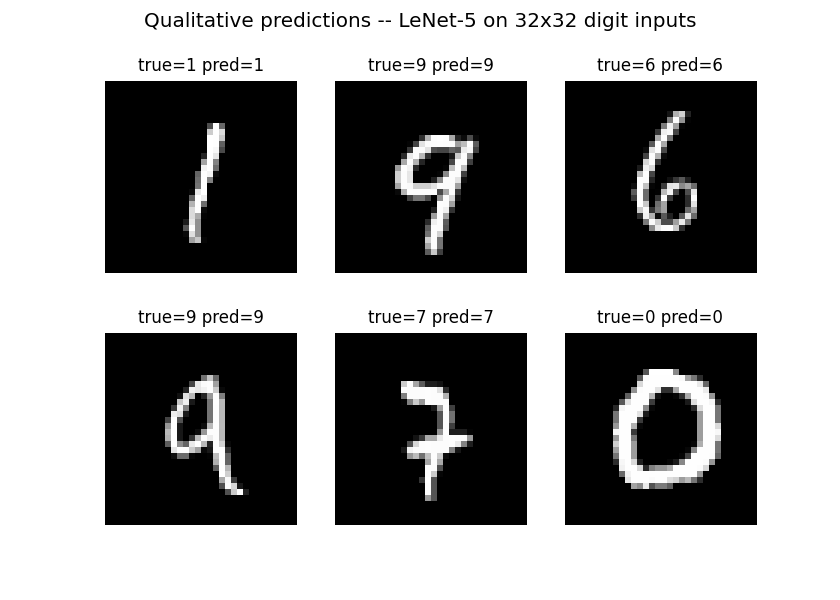

In [14]:

# ============================================================================
# 6. VISUALIZATION -- STYLING (white background, black text, everywhere)
# ============================================================================

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "legend.labelcolor": "black",
})


def show_figure_inline(fig):
    """Render a matplotlib figure to an in-memory PNG buffer and display it inline."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120, facecolor="white")
    plt.close(fig)
    buf.seek(0)
    display(IPyImage(data=buf.read()))


# --- Qualitative sample-prediction grid (image task -> show the images) ---
fig_samples, axes_s = plt.subplots(2, 3, figsize=(7, 5))
fig_samples.patch.set_facecolor("white")
for ax, i in zip(axes_s.flat, sample_idx):
    x_i, y_true = val_ds[i]
    with torch.no_grad():
        out_i = model(x_i.unsqueeze(0).to(device))
        pred_i = predict(out_i).item()
    ax.imshow(x_i.squeeze(0).numpy(), cmap="gray")
    ax.set_title(f"true={y_true.item()} pred={pred_i}", color="black", fontsize=10)
    ax.axis("off")
fig_samples.suptitle("Qualitative predictions -- LeNet-5 on 32x32 digit inputs", color="black")
show_figure_inline(fig_samples)

/tmp/ipykernel_847/2308567720.py:126: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  im = Image.fromarray((np.clip(img01, 0, 1) * 255).astype(np.uint8), mode="L")
/tmp/ipykernel_847/2308567720.py:266: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.04, 1, 0.90])


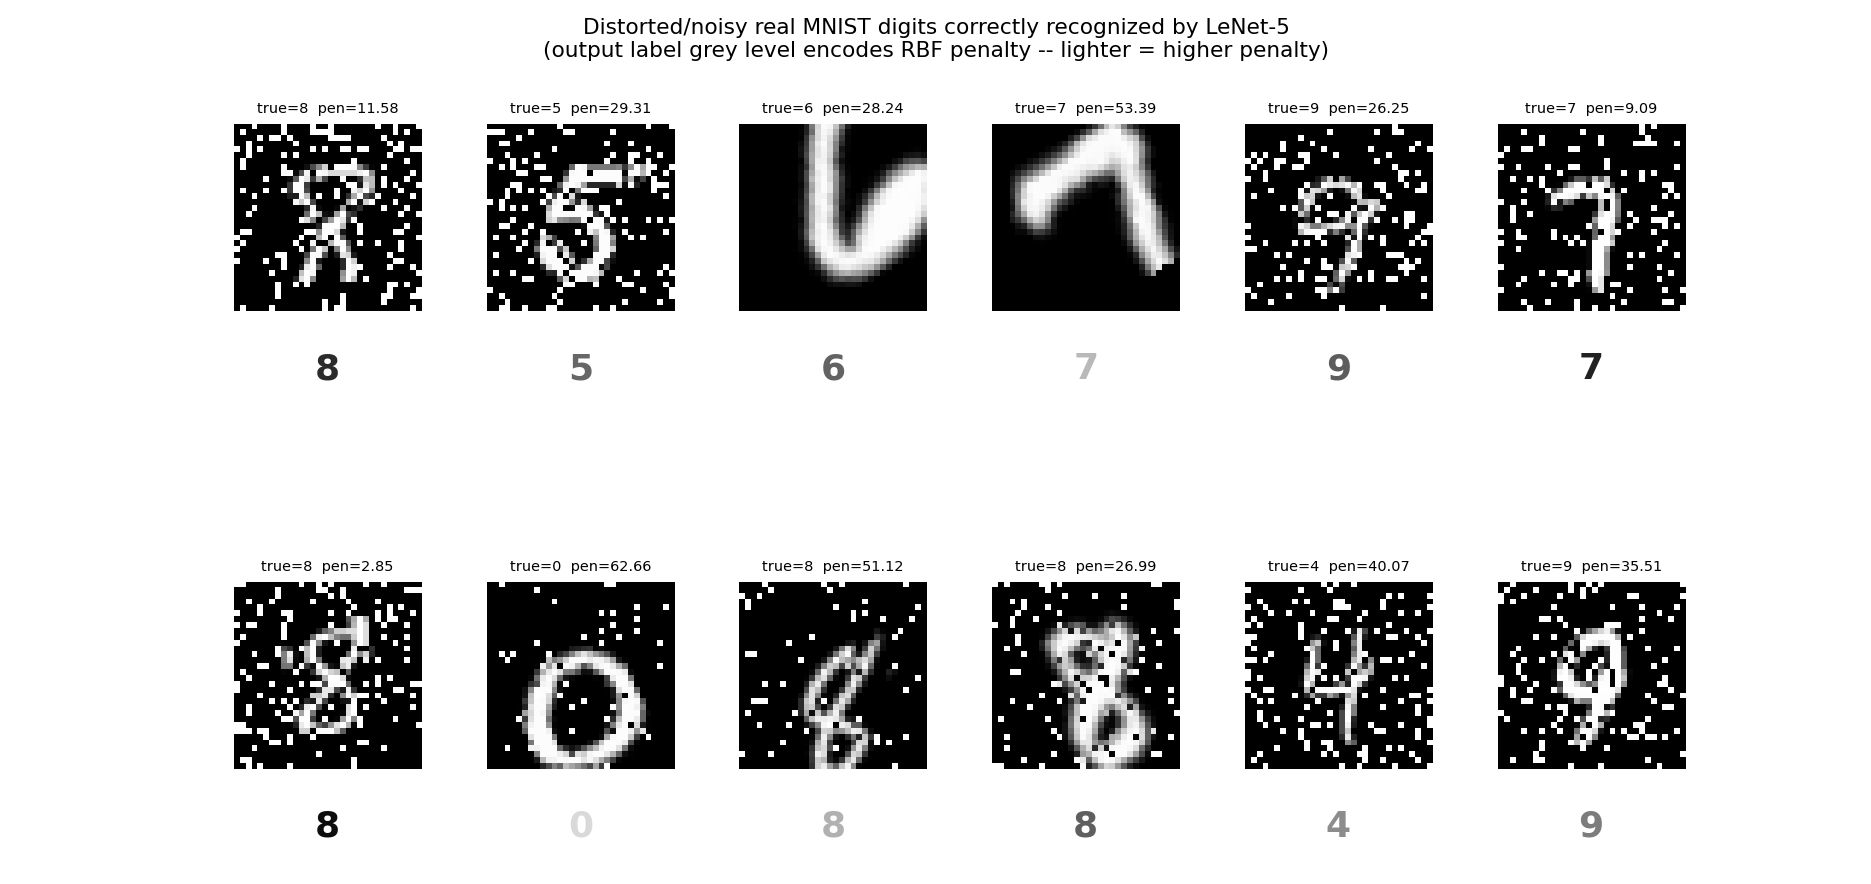

In [15]:
"""
============================================================================
FIGURE 13 REPLICATION
"Examples of unusual, distorted, and noisy characters correctly recognized
by LeNet-5." (LeCun et al., 1998, Sec. III-D, Fig. 13)

Paper caption (verbatim intent): "The grey level of the output label
represents the penalty (lighter for higher penalties)."

WHAT THIS CELL DOES
--------------------
1. Pulls CLEAN, REAL MNIST digit images from the Hugging Face Hub test
   split (`hf_mnist_test`) as the base images -- no synthetic digits.
2. Applies heavy distortions / noise on top of those real digits --
   large rotations, scale changes, shifts, and salt-and-pepper noise --
   mirroring the perturbations the paper describes in Sec. III-D
   ("scale variations up to about a factor of two, vertical shift
   variations of plus or minus about half the height of the character,
   and rotations up to plus or minus 30 degrees" + salt-and-pepper noise
   with per-pixel inversion probability 0.1).
3. Runs them through the ALREADY-TRAINED LeNet-5 `model` from the
   previous cell (RBF output layer, Eq. 7).
4. Keeps only examples the model classifies CORRECTLY, exactly like the
   paper's figure, which only shows successfully recognized distortions.
5. Renders a grid where, under each thumbnail, the PREDICTED digit label
   is drawn in a grey level proportional to its RBF penalty -- LIGHTER
   grey = HIGHER penalty (less confident), DARKER grey = LOWER penalty
   (more confident) -- reproducing the paper's exact visual convention.

COMPATIBILITY NOTE
-------------------
This cell reuses `model`, `device`, `CLASSES`, `predict`, and the real
MNIST Hugging Face split `hf_mnist_test` defined in the previous LeNet-5
training/dataset cell. Run that cell first.
============================================================================
"""

import io
import random

import numpy as np
import torch
import torch.nn.functional as F

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display, Image as IPyImage

# ----------------------------------------------------------------------
# Guard: make sure the trained LeNet-5 model and real MNIST split exist
# ----------------------------------------------------------------------
_required = ["model", "device", "CLASSES", "predict", "hf_mnist_test"]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        f"Missing objects from the training cell: {_missing}. "
        f"Please run the LeNet-5 training/dataset cell before this one."
    )

random.seed(123)
np.random.seed(123)
torch.manual_seed(123)

# ----------------------------------------------------------------------
# Global white-background / black-text styling (matches the rest of the lab)
# ----------------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.edgecolor": "black",
})


# ============================================================================
# 1. Base-image lookup + distortion / noise generator
# Mirrors Fig. 13's perturbations: rotation, scale, shift, salt-and-pepper
# noise, applied on top of REAL MNIST digits. This is a STRESS TEST, not
# new training data -- it only probes the already-trained model's
# robustness (Sec. III-D).
# ============================================================================

# Pre-index the real MNIST test split by label, once, for fast lookup.
_label_to_indices = {d: [] for d in range(10)}
for i, lbl in enumerate(hf_mnist_test["label"]):
    _label_to_indices[int(lbl)].append(i)


def get_base_image_for_label(label):
    """
    Returns a clean 32x32, [0,1]-range base image for `label`, drawn
    directly from the real Hugging Face MNIST test split. The raw 28x28
    digit is zero-padded to 32x32 (Sec. II-B input size), matching how the
    training/dataset cell prepares real MNIST images.
    """
    idx = random.choice(_label_to_indices[label])
    example = hf_mnist_test[idx]
    img = example["image"]  # PIL.Image, mode "L", size (28, 28)
    if img.mode != "L":
        img = img.convert("L")

    padded = Image.new("L", (32, 32), color=0)
    padded.paste(img, (2, 2))

    arr = np.asarray(padded, dtype=np.float32) / 255.0  # -> [0, 1]
    return arr


def apply_heavy_distortion(img01, rotate_deg=None, scale=None, shift_px=None,
                            salt_pepper_p=0.0):
    """
    Applies an affine distortion (rotation + scale + translation) followed
    by salt-and-pepper noise, on a [0,1]-range 32x32 numpy image.

    Paper reference (Sec. III-D): "accurate recognition occurs for scale
    variations up to about a factor of two, vertical shift variations of
    plus or minus about half the height of the character, and rotations
    up to plus or minus 30 degrees." Salt-and-pepper noise: "each pixel
    was randomly inverted with probability 0.1" (Fig. 13 caption context).
    """
    size = img01.shape[0]
    im = Image.fromarray((np.clip(img01, 0, 1) * 255).astype(np.uint8), mode="L")

    if scale is not None:
        new_size = max(8, int(size * scale))
        im = im.resize((new_size, new_size), resample=Image.BILINEAR)
        canvas = Image.new("L", (size, size), color=0)
        off = (size - new_size) // 2
        canvas.paste(im, (off, off))
        im = canvas

    if rotate_deg is not None:
        im = im.rotate(rotate_deg, resample=Image.BILINEAR, fillcolor=0)

    if shift_px is not None:
        dx, dy = shift_px
        im = im.transform((size, size), Image.AFFINE, (1, 0, -dx, 0, 1, -dy))

    arr = np.asarray(im, dtype=np.float32) / 255.0

    if salt_pepper_p > 0:
        mask = np.random.rand(size, size) < salt_pepper_p
        arr = np.where(mask, 1.0 - arr, arr)  # invert pixel where masked

    return arr


def build_stress_test_batch(n_display=12, n_attempts=200):
    """
    Generates heavily distorted/noisy REAL digit examples, runs them
    through `model`, and keeps only the ones LeNet-5 gets RIGHT --
    matching the paper's Fig. 13, which only shows successfully
    recognized distortions. Returns lists of raw images, true labels,
    predicted labels, and RBF penalty of the predicted class.
    """
    model.eval()
    kept_imgs, kept_true, kept_pred, kept_penalty = [], [], [], []

    distortion_specs = [
        dict(rotate_deg=30, scale=1.7, shift_px=(3, -4), salt_pepper_p=0.0),
        dict(rotate_deg=-28, scale=0.6, shift_px=(-3, 4), salt_pepper_p=0.0),
        dict(rotate_deg=0, scale=1.0, shift_px=(0, 0), salt_pepper_p=0.15),
        dict(rotate_deg=15, scale=1.3, shift_px=(2, 3), salt_pepper_p=0.10),
        dict(rotate_deg=-15, scale=0.8, shift_px=(-2, -3), salt_pepper_p=0.10),
        dict(rotate_deg=25, scale=1.0, shift_px=(0, 6), salt_pepper_p=0.05),
    ]

    attempt = 0
    while len(kept_imgs) < n_display and attempt < n_attempts:
        attempt += 1
        label = random.randint(0, 9)
        base = get_base_image_for_label(label)
        spec = random.choice(distortion_specs)
        distorted = apply_heavy_distortion(base, **spec)

        x = distorted * 1.275 - 0.1  # same paper-style normalization as training
        x_t = torch.from_numpy(x).float().unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            penalties = model(x_t)               # (1, 10) RBF penalties, Eq. 7
            pred = predict(penalties).item()      # argmin penalty
            pred_penalty = penalties[0, pred].item()

        if pred == label:
            kept_imgs.append(distorted)
            kept_true.append(label)
            kept_pred.append(pred)
            kept_penalty.append(pred_penalty)

    return kept_imgs, kept_true, kept_pred, kept_penalty


imgs, true_labels, pred_labels, penalties = build_stress_test_batch(n_display=12)

if len(imgs) == 0:
    print("No correctly-recognized distorted samples were found in this "
          "attempt budget -- the demo model may be undertrained (expected "
          "for a 5-epoch educational run). Try re-running the training cell "
          "for more epochs, or increase n_attempts.")
else:
    # ----------------------------------------------------------------------
    # 2. Normalize penalties -> grey levels for the OUTPUT LABEL text
    # Paper convention: LIGHTER grey = HIGHER penalty, DARKER grey = LOWER
    # penalty. We map normalized penalty in [0,1] to a grey value in
    # [0.05 (near-black, low penalty), 0.85 (light grey, high penalty)],
    # keeping the label always visible against the white panel background.
    # ----------------------------------------------------------------------
    penalties = np.array(penalties, dtype=np.float32)
    p_min, p_max = penalties.min(), penalties.max()
    if p_max > p_min:
        norm_penalty = (penalties - p_min) / (p_max - p_min)
    else:
        norm_penalty = np.zeros_like(penalties)  # all identical -> all dark

    GREY_DARK, GREY_LIGHT = 0.05, 0.85
    label_grey = GREY_DARK + norm_penalty * (GREY_LIGHT - GREY_DARK)

    # ----------------------------------------------------------------------
    # 3. Render the Fig. 13-style grid
    # ----------------------------------------------------------------------
    n = len(imgs)
    n_cols = min(6, n)
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(2.4 * n_cols, 3.4 * n_rows),   # taller per row -> room for both title and label
        gridspec_kw={"hspace": 1.05, "wspace": 0.35},  # more vertical gap between rows
    )
    fig.patch.set_facecolor("white")
    axes = np.atleast_1d(axes).reshape(-1)

    for i in range(n_rows * n_cols):
        ax = axes[i]
        ax.set_facecolor("white")
        ax.axis("off")
        if i >= n:
            continue

        ax.imshow(imgs[i], cmap="gray", vmin=0, vmax=1)

        # Small black caption (true label + numeric penalty) ABOVE the image
        ax.set_title(f"true={true_labels[i]}  pen={penalties[i]:.2f}",
                    fontsize=8, color="black", pad=6)

        # Predicted label BELOW the image, grey level encodes RBF penalty.
        g = label_grey[i]
        label_color = (g, g, g)
        ax.text(
            0.5, -0.22, f"{pred_labels[i]}",
            transform=ax.transAxes, ha="center", va="top",
            fontsize=20, fontweight="bold", color=label_color,
        )

    fig.suptitle(
        "Distorted/noisy real MNIST digits correctly recognized by LeNet-5\n"
        "(output label grey level encodes RBF penalty -- lighter = higher penalty)",
        color="black", fontsize=12,
    )
    # Reserve top margin for suptitle and bottom margin so the last row's
    # large predicted-label glyphs are never clipped by the figure edge.
    fig.tight_layout(rect=[0, 0.04, 1, 0.90])

    # ----------------------------------------------------------------------
    # 4. Display via in-memory buffer (no disk writes, no plt.show())
    # ----------------------------------------------------------------------
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=130, facecolor="white")
    plt.close(fig)
    buf.seek(0)
    display(IPyImage(data=buf.read()))

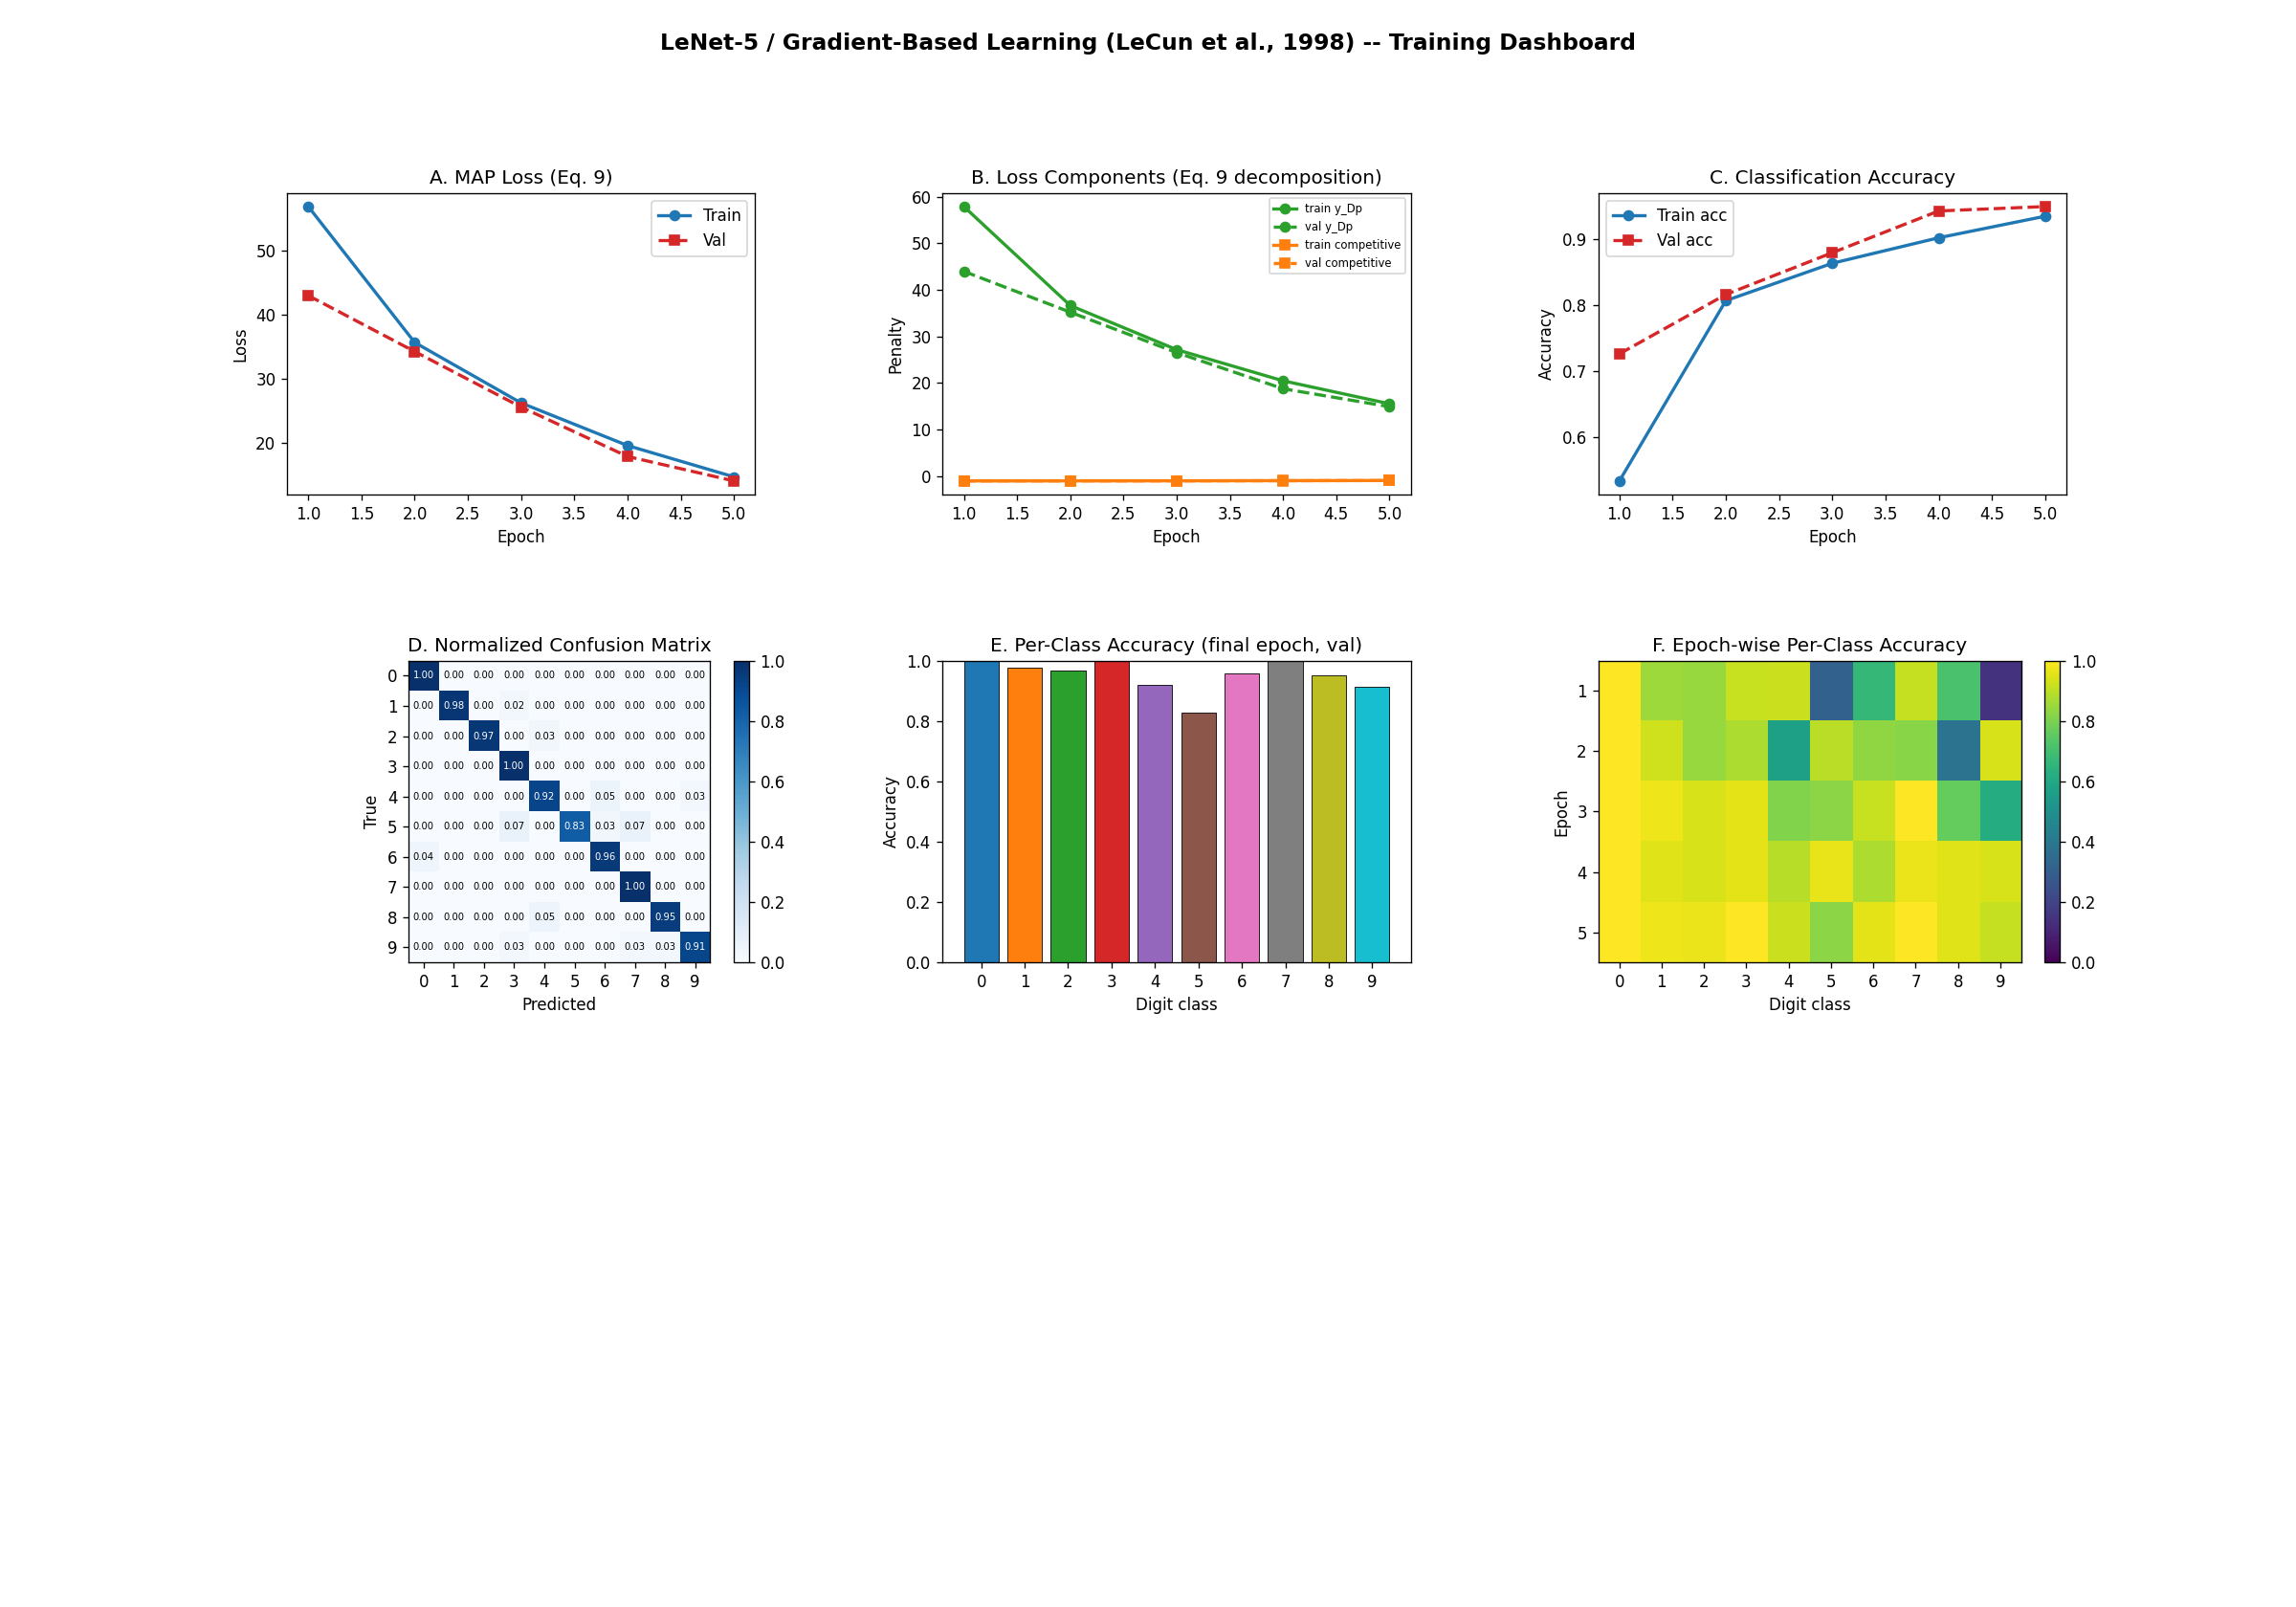

In [19]:
# ============================================================================
# 7. FINAL SUMMARY DASHBOARD (8 labeled panels A-H, 3-row GridSpec)
# COLORED VERSION — white background + black text/axes (per styling reqs),
# but plot elements (lines, bars, heatmaps, confusion matrix) now use color
# instead of black/white/grey only.
# ============================================================================

epochs_range = list(range(1, N_EPOCHS + 1))

# --- Color palette (consistent across the whole dashboard) ---------------
COLOR_TRAIN = "#1f77b4"       # blue
COLOR_VAL = "#d62728"         # red
COLOR_YCORRECT = "#2ca02c"    # green
COLOR_COMPETITIVE = "#ff7f0e" # orange
COLOR_CORRECT_HIST = "#2ca02c"   # green
COLOR_INCORRECT_HIST = "#d62728" # red
CLASS_COLORS = plt.cm.tab10(np.linspace(0, 1, 10))  # 10 distinct colors, one per digit class
CMAP_CONFUSION = "Blues"
CMAP_HEATMAP = "viridis"

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor("white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# ---- Panel A: total training/validation loss (Eq. 9, primary objective) ----
axA = fig.add_subplot(gs[0, 0])
axA.plot(epochs_range, history["train_loss"], color=COLOR_TRAIN, marker="o", linewidth=2, label="Train")
axA.plot(epochs_range, history["val_loss"], color=COLOR_VAL, marker="s", linestyle="--", linewidth=2, label="Val")
axA.set_title("A. MAP Loss (Eq. 9)", color="black")
axA.set_xlabel("Epoch", color="black"); axA.set_ylabel("Loss", color="black")
axA.legend(); axA.tick_params(colors="black")
for s in axA.spines.values(): s.set_color("black")

# ---- Panel B: decomposed loss components (correct-class term vs. competitive term) ----
axB = fig.add_subplot(gs[0, 1])
axB.plot(epochs_range, history["train_ycorrect"], color=COLOR_YCORRECT, marker="o", linewidth=2, label="train y_Dp")
axB.plot(epochs_range, history["val_ycorrect"], color=COLOR_YCORRECT, marker="o", linestyle="--", linewidth=2, label="val y_Dp")
axB.plot(epochs_range, history["train_competitive"], color=COLOR_COMPETITIVE, marker="s", linewidth=2, label="train competitive")
axB.plot(epochs_range, history["val_competitive"], color=COLOR_COMPETITIVE, marker="s", linestyle="--", linewidth=2, label="val competitive")
axB.set_title("B. Loss Components (Eq. 9 decomposition)", color="black")
axB.set_xlabel("Epoch", color="black"); axB.set_ylabel("Penalty", color="black")
axB.legend(fontsize=7); axB.tick_params(colors="black")
for s in axB.spines.values(): s.set_color("black")

# ---- Panel C: accuracy curves (paper's evaluation metric, Sec. III-B, Fig. 9) ----
axC = fig.add_subplot(gs[0, 2])
axC.plot(epochs_range, history["train_acc"], color=COLOR_TRAIN, marker="o", linewidth=2, label="Train acc")
axC.plot(epochs_range, history["val_acc"], color=COLOR_VAL, marker="s", linestyle="--", linewidth=2, label="Val acc")
axC.set_title("C. Classification Accuracy", color="black")
axC.set_xlabel("Epoch", color="black"); axC.set_ylabel("Accuracy", color="black")
axC.legend(); axC.tick_params(colors="black")
for s in axC.spines.values(): s.set_color("black")

# ---- Panel D: normalized confusion matrix ----
# A standard confusion matrix DIRECTLY applies here (unlike sequence/
# generation tasks) because the paper's task is genuine 10-way
# classification over discrete digit classes (Sec. III, Fig. 9).
axD = fig.add_subplot(gs[1, 0])
imD = axD.imshow(confusion_norm, cmap=CMAP_CONFUSION, vmin=0, vmax=1)
axD.set_xticks(range(10)); axD.set_yticks(range(10))
axD.set_xticklabels(CLASSES, color="black"); axD.set_yticklabels(CLASSES, color="black")
axD.set_xlabel("Predicted", color="black"); axD.set_ylabel("True", color="black")
axD.set_title("D. Normalized Confusion Matrix", color="black")
for i in range(10):
    for j in range(10):
        v = confusion_norm[i, j]
        axD.text(j, i, f"{v:.2f}", ha="center", va="center",
                  color="white" if v > 0.5 else "black", fontsize=6)
cbarD = plt.colorbar(imD, ax=axD, fraction=0.046)
cbarD.ax.yaxis.set_tick_params(color="black")
plt.setp(cbarD.ax.get_yticklabels(), color="black")

# ---- Panel E: per-class accuracy bar chart ----
axE = fig.add_subplot(gs[1, 1])
final_per_class = history["per_class_acc_by_epoch"][-1]
axE.bar(CLASSES, final_per_class, color=CLASS_COLORS, edgecolor="black", linewidth=0.5)
axE.set_title("E. Per-Class Accuracy (final epoch, val)", color="black")
axE.set_xlabel("Digit class", color="black"); axE.set_ylabel("Accuracy", color="black")
axE.set_ylim(0, 1); axE.tick_params(colors="black")
for s in axE.spines.values(): s.set_color("black")

# ---- Panel F: epoch-wise per-class accuracy heatmap ----
axF = fig.add_subplot(gs[1, 2])
heat = np.stack(history["per_class_acc_by_epoch"], axis=0)  # (N_EPOCHS, 10)
imF = axF.imshow(heat, cmap=CMAP_HEATMAP, aspect="auto", vmin=0, vmax=1)
axF.set_xticks(range(10)); axF.set_xticklabels(CLASSES, color="black")
axF.set_yticks(range(N_EPOCHS)); axF.set_yticklabels(epochs_range, color="black")
axF.set_xlabel("Digit class", color="black"); axF.set_ylabel("Epoch", color="black")
axF.set_title("F. Epoch-wise Per-Class Accuracy", color="black")
cbarF = plt.colorbar(imF, ax=axF, fraction=0.046)
cbarF.ax.yaxis.set_tick_params(color="black")
plt.setp(cbarF.ax.get_yticklabels(), color="black")

fig.suptitle("LeNet-5 / Gradient-Based Learning (LeCun et al., 1998) -- Training Dashboard",
              color="black", fontsize=14, fontweight="bold")

show_figure_inline(fig)